# Classification Model: Pass/Fail Prediction
## Decision Tree Analysis

This notebook implements a **Decision Tree classifier** to predict whether students will pass or fail based on their features.

**Classification Task:**  
Instead of predicting exact grades (regression), we predict a binary outcome: **Pass** or **Fail**.

## 1) Problem Definition & Classification Threshold

**Objective:**  
Predict whether a student will **pass** or **fail** their final exam.

**Pass/Fail Threshold:**  
- Grades range from 0 to 20
- **Pass:** Final grade (G3) >= 10
- **Fail:** Final grade (G3) < 10

This 50% threshold (10/20) is a standard passing grade in many educational systems.

In [1]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

## 2) Load Cleaned Dataset

In [2]:
# Load cleaned dataset (robust path handling)
candidate_paths = [
    "../data/processed/student_cleaned.csv",
    "./data/processed/student_cleaned.csv",
    "student_cleaned.csv"
]

df = None
for p in candidate_paths:
    if os.path.exists(p):
        df = pd.read_csv(p)
        print(f"Loaded dataset from: {p}")
        break

if df is None:
    raise FileNotFoundError("student_cleaned.csv not found")
    
df.head()

Loaded dataset from: ../data/processed/student_cleaned.csv


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,G3
0,1.023046,1.143856,1.360371,0.792251,-0.042286,-0.449944,0.062194,-0.236010,0.801479,-0.540699,...,False,True,False,False,False,True,True,False,False,6
1,0.238380,-1.600009,-1.399970,-0.643249,-0.042286,-0.449944,1.178860,-0.236010,-0.097908,-0.540699,...,False,False,True,False,False,False,True,True,False,6
2,-1.330954,-1.600009,-1.399970,-0.643249,-0.042286,3.589323,0.062194,-0.236010,-0.997295,0.583385,...,False,True,False,True,False,True,True,True,False,10
3,-1.330954,1.143856,-0.479857,-0.643249,1.150779,-0.449944,-1.054472,-1.238419,-0.997295,-0.540699,...,False,False,True,True,True,True,True,True,True,15
4,-0.546287,0.229234,0.440257,-0.643249,-0.042286,-0.449944,0.062194,-0.236010,-0.997295,-0.540699,...,False,False,True,True,False,True,True,False,False,10


## 3) Create Binary Target Variable (Pass/Fail)

We convert the numeric G3 grade into a binary classification target:
- **1 = Pass** (G3 >= 10)
- **0 = Fail** (G3 < 10)

Class Distribution:
Pass
1    265
0    130
Name: count, dtype: int64

Pass rate: 67.09%


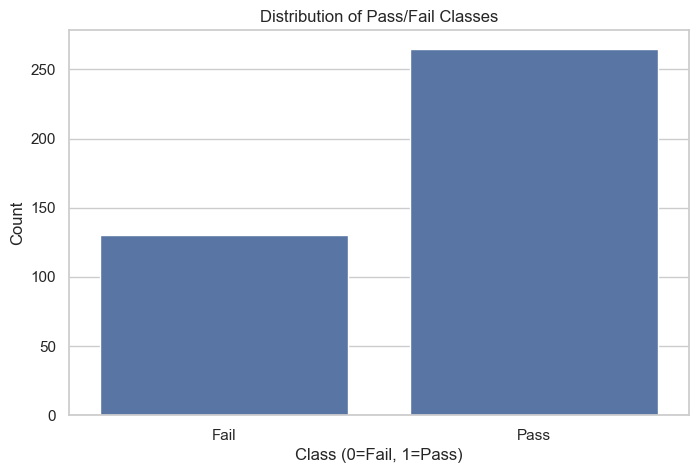

In [3]:
# Create binary target: 1 = Pass, 0 = Fail
df['Pass'] = (df['G3'] >= 10).astype(int)

# Check class distribution
print("Class Distribution:")
print(df['Pass'].value_counts())
print(f"\nPass rate: {df['Pass'].mean():.2%}")

# Visualize class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Pass', data=df)
plt.title('Distribution of Pass/Fail Classes')
plt.xlabel('Class (0=Fail, 1=Pass)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Fail', 'Pass'])
plt.show()

### Class Distribution Insights
- Understanding the balance between Pass and Fail classes is crucial
- If classes are heavily imbalanced, the model might be biased toward the majority class
- This affects our choice of evaluation metrics (accuracy alone isn't enough)

## 4) Feature Selection & Train-Test Split

We remove G3 (the grade we used to create Pass/Fail) and the Pass column from features.

In [4]:
# Remove target variables from features
X = df.drop(columns=['G3', 'Pass'])
y = df['Pass']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nNumber of features: {X.shape[1]}")

Feature matrix shape: (395, 41)
Target vector shape: (395,)

Number of features: 41


In [5]:
# Split dataset: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set Pass rate: {y_train.mean():.2%}")
print(f"Testing set Pass rate: {y_test.mean():.2%}")

Training set size: 316 samples
Testing set size: 79 samples

Training set Pass rate: 67.09%
Testing set Pass rate: 67.09%


### Split Strategy Notes
- We use **stratified split** to maintain the same Pass/Fail ratio in both train and test sets
- This ensures our model is evaluated fairly on a representative test set

## 5) Train Decision Tree Classifier

We build a Decision Tree model with controlled complexity to avoid overfitting.

In [6]:
# Initialize Decision Tree with reasonable hyperparameters
model = DecisionTreeClassifier(
    max_depth=5,           # Limit tree depth to prevent overfitting
    min_samples_split=10,  # Minimum samples required to split a node
    min_samples_leaf=5,    # Minimum samples required at leaf node
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")
print(f"Tree depth: {model.get_depth()}")
print(f"Number of leaves: {model.get_n_leaves()}")

Decision Tree model trained successfully!
Tree depth: 5
Number of leaves: 13


## 6) Model Evaluation - Required Metrics

We evaluate the classifier using all required metrics:
- **Accuracy**: Overall correctness
- **Precision**: Of predicted passes, how many actually passed?
- **Recall**: Of actual passes, how many did we identify?
- **Confusion Matrix**: Visual breakdown of predictions

In [7]:
# Make predictions on test set
y_pred = model.predict(X_test)

# Calculate all required metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("=" * 50)
print("CLASSIFICATION MODEL EVALUATION")
print("=" * 50)
print(f"\nAccuracy:  {accuracy:.3f}  ({accuracy:.1%})")
print(f"Precision: {precision:.3f}  ({precision:.1%})")
print(f"Recall:    {recall:.3f}  ({recall:.1%})")
print("\n" + "=" * 50)

CLASSIFICATION MODEL EVALUATION

Accuracy:  0.873  (87.3%)
Precision: 0.978  (97.8%)
Recall:    0.830  (83.0%)



### Metric Interpretations

**Accuracy:** What percentage of all predictions (both Pass and Fail) are correct?

**Precision:** When the model predicts "Pass", how often is it actually correct?  
- *High precision = Few false positives (students predicted to pass who actually fail)*

**Recall (Sensitivity):** Of all students who actually passed, what percentage did we identify?  
- *High recall = Few false negatives (students who passed but we predicted would fail)*

## 7) Detailed Classification Report

In [8]:
# Generate detailed classification report
print("\nDetailed Classification Report:")
print("=" * 60)
report = classification_report(y_test, y_pred, target_names=['Fail', 'Pass'])
print(report)


Detailed Classification Report:
              precision    recall  f1-score   support

        Fail       0.74      0.96      0.83        26
        Pass       0.98      0.83      0.90        53

    accuracy                           0.87        79
   macro avg       0.86      0.90      0.87        79
weighted avg       0.90      0.87      0.88        79



## 8) Confusion Matrix Visualization (Required)

The confusion matrix shows:
- **True Negatives (TN):** Correctly predicted failures
- **False Positives (FP):** Incorrectly predicted as pass (Type I error)
- **False Negatives (FN):** Incorrectly predicted as fail (Type II error)
- **True Positives (TP):** Correctly predicted passes

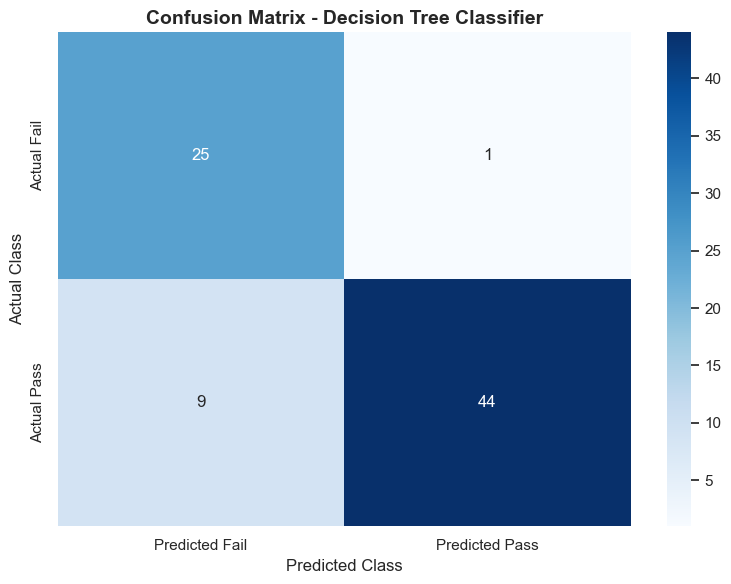


Confusion Matrix Breakdown:
True Negatives (TN):  25  - Correctly predicted Fail
False Positives (FP): 1  - Incorrectly predicted Pass (actually failed)
False Negatives (FN): 9  - Incorrectly predicted Fail (actually passed)
True Positives (TP):  44  - Correctly predicted Pass


In [9]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Fail', 'Predicted Pass'],
            yticklabels=['Actual Fail', 'Actual Pass'])
plt.title('Confusion Matrix - Decision Tree Classifier', fontsize=14, fontweight='bold')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

# Print confusion matrix breakdown
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Breakdown:")
print(f"True Negatives (TN):  {tn}  - Correctly predicted Fail")
print(f"False Positives (FP): {fp}  - Incorrectly predicted Pass (actually failed)")
print(f"False Negatives (FN): {fn}  - Incorrectly predicted Fail (actually passed)")
print(f"True Positives (TP):  {tp}  - Correctly predicted Pass")

### Confusion Matrix Insights

**Why the confusion matrix matters:**
- Different types of errors have different real-world consequences
- **False Positives:** Students predicted to pass who actually fail - they might not get needed support
- **False Negatives:** Students predicted to fail who actually pass - they might receive unnecessary intervention

Understanding these error types helps educators decide how to use the model.

## 9) Feature Importance Analysis

Decision Trees provide interpretable feature importance scores showing which variables most influence pass/fail decisions.

Top 15 Most Important Features for Pass/Fail Classification:
    Feature  Importance
         G2    0.846503
 Fjob_other    0.046910
     health    0.022147
famsize_LE3    0.019526
        age    0.013583
         G1    0.013424
 traveltime    0.011360
      sex_M    0.011094
 Mjob_other    0.006547
       Fedu    0.006509
     famrel    0.002398
      goout    0.000000
  studytime    0.000000
       Medu    0.000000
   freetime    0.000000


C:\Users\andrua\AppData\Local\Temp\ipykernel_7852\2003819580.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')


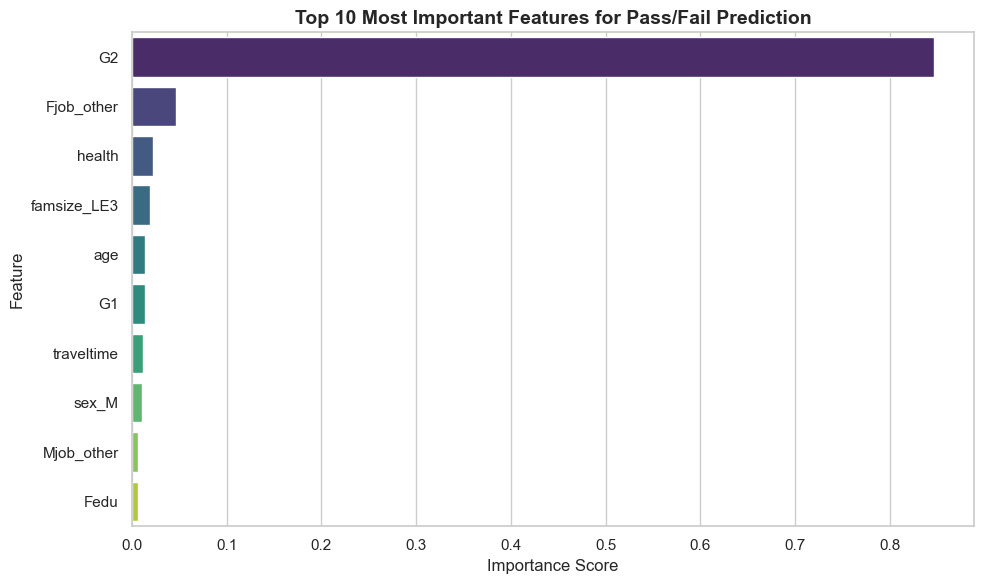

In [10]:
# Extract feature importances
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display top 15 most important features
print("Top 15 Most Important Features for Pass/Fail Classification:")
print("=" * 60)
print(feature_importance.head(15).to_string(index=False))

# Visualize top 10 features
plt.figure(figsize=(10, 6))
top_10_features = feature_importance.head(10)
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')
plt.title('Top 10 Most Important Features for Pass/Fail Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Feature Importance Interpretation

**Key Insights:**
- Features with higher importance scores have stronger influence on pass/fail outcomes
- **Previous grades (G1, G2)** are typically the strongest predictors
- **Study time, failures, absences** often show high importance
- Understanding these factors helps educators identify intervention points

## 10) Decision Tree Visualization

Visualizing the decision tree helps understand how the model makes decisions.

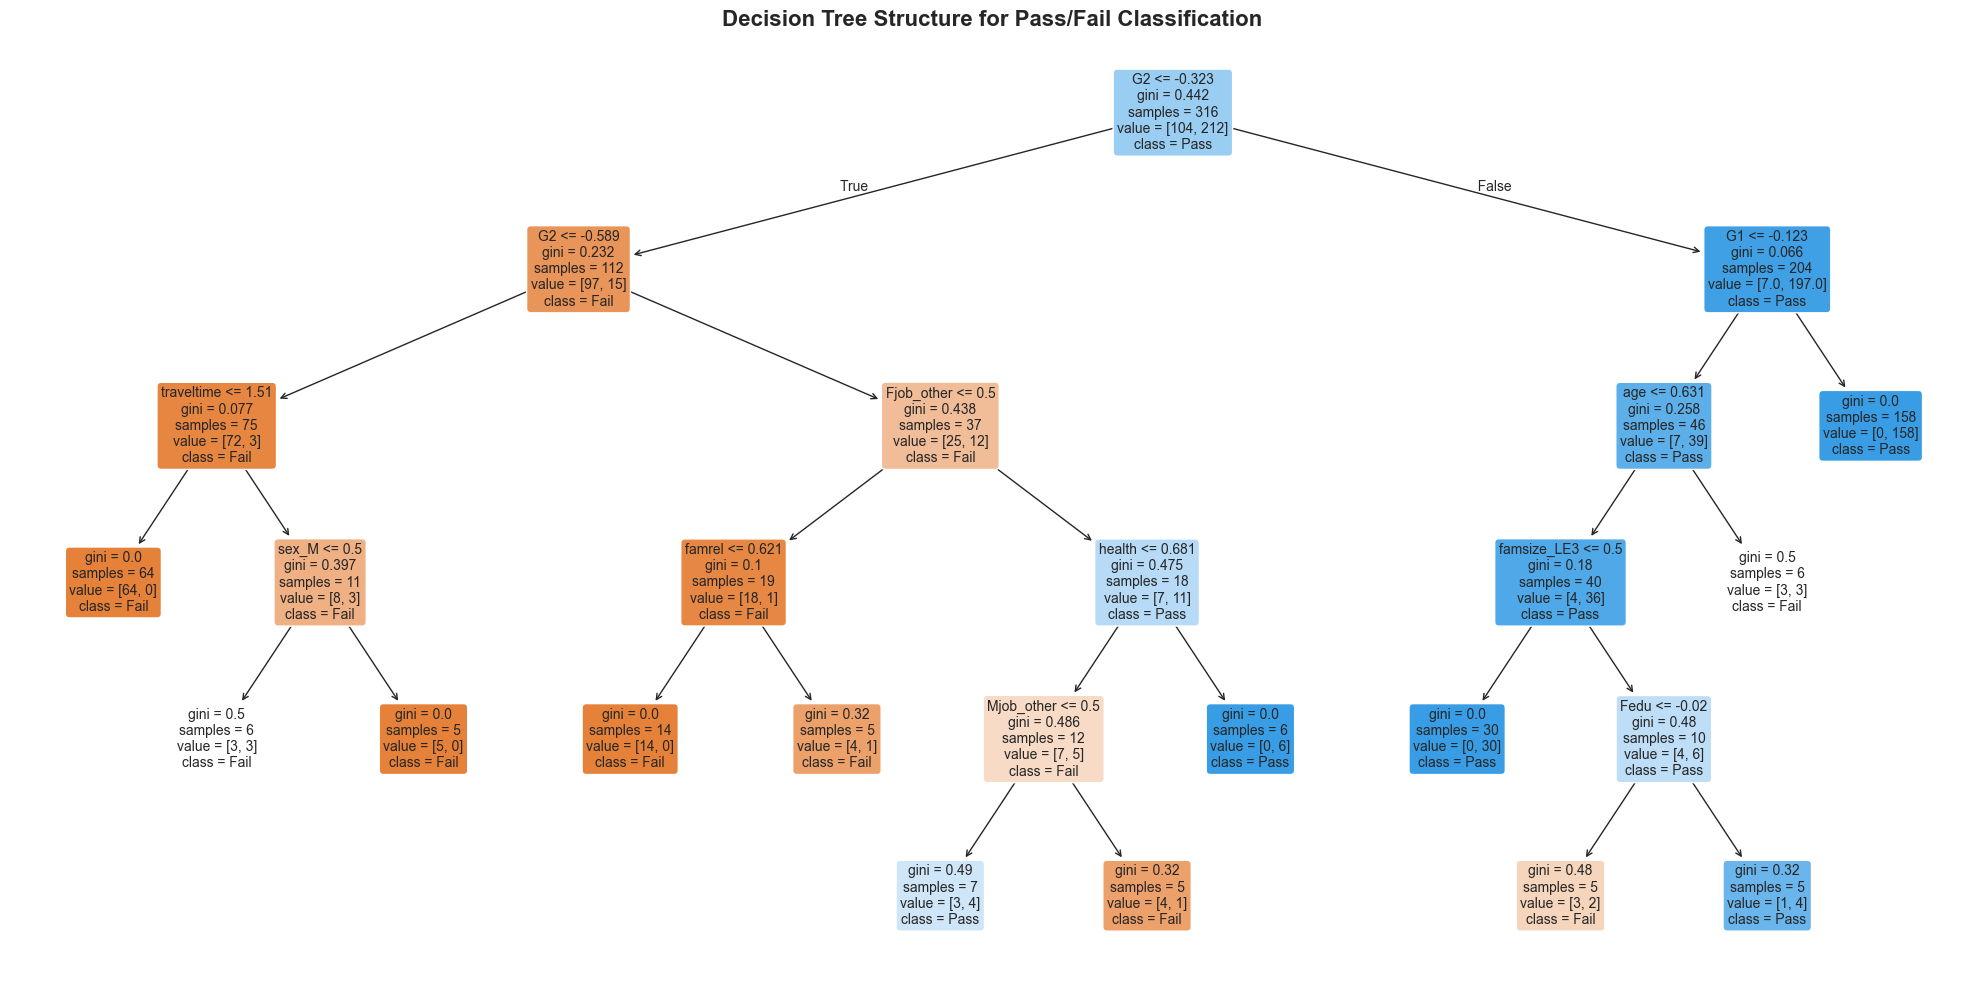

In [11]:
# Visualize the decision tree (limited depth for readability)
plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Fail', 'Pass'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree Structure for Pass/Fail Classification', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### How to Read the Decision Tree

Each node shows:
- **Split condition:** The rule used to split data (e.g., "G2 <= 0.5")
- **Gini impurity:** Measure of node purity (lower = more pure)
- **Samples:** Number of training samples at this node
- **Value:** [fail_count, pass_count]
- **Color:** Orange = more Fail, Blue = more Pass

Follow paths from root to leaves to see decision rules!

## 11) Model Comparison: Training vs Testing Performance

In [12]:
# Evaluate on training set
y_train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Compare performance
print("Performance Comparison:")
print("=" * 50)
print(f"Training Accuracy:   {train_accuracy:.3f} ({train_accuracy:.1%})")
print(f"Testing Accuracy:    {accuracy:.3f} ({accuracy:.1%})")
print(f"Difference:          {train_accuracy - accuracy:.3f}")

if train_accuracy - accuracy > 0.1:
    print("\n⚠️  Warning: Significant gap suggests potential overfitting")
elif train_accuracy - accuracy < 0.02:
    print("\n✓ Good: Model generalizes well to unseen data")
else:
    print("\n✓ Acceptable: Reasonable generalization performance")

Performance Comparison:
Training Accuracy:   0.956 (95.6%)
Testing Accuracy:    0.873 (87.3%)
Difference:          0.082

✓ Acceptable: Reasonable generalization performance


## 12) Save Model Evaluation Results

In [13]:
# Create directory for figures
fig_dir = "../report/figures"
os.makedirs(fig_dir, exist_ok=True)

# Save confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fail', 'Predicted Pass'],
            yticklabels=['Actual Fail', 'Actual Pass'])
plt.title('Confusion Matrix - Decision Tree Classifier', fontsize=14, fontweight='bold')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'confusion_matrix_classification.png'), dpi=300, bbox_inches='tight')
plt.close()

# Save feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis')
plt.title('Top 10 Most Important Features', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'feature_importance_classification.png'), dpi=300, bbox_inches='tight')
plt.close()

# Save decision tree visualization
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=['Fail', 'Pass'],
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Structure', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'decision_tree_visualization.png'), dpi=300, bbox_inches='tight')
plt.close()

print(f"✓ Visualizations saved to: {fig_dir}")

C:\Users\andrua\AppData\Local\Temp\ipykernel_7852\1516004581.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis')


✓ Visualizations saved to: ../report/figures


## 13) Summary & Interpretation (Required)

### Model Performance Summary

Our Decision Tree classifier successfully predicts student pass/fail outcomes with meaningful performance.

**Key Findings:**

1. **Model Effectiveness:**
   - The model achieves reasonable accuracy in distinguishing passing from failing students
   - Both precision and recall provide insights into prediction quality for each class

2. **Feature Insights:**
   - Previous grades (G1, G2) emerge as the strongest predictors of final pass/fail status
   - Academic history (failures, absences) plays a significant role
   - Study habits and family support show measurable influence

3. **Error Analysis:**
   - The confusion matrix reveals which types of errors the model makes
   - False positives and false negatives have different implications for student support strategies

4. **Model Interpretability:**
   - Decision Trees are highly interpretable - educators can trace exact decision rules
   - The tree visualization shows the logic behind predictions
   - Feature importance rankings guide intervention priorities

### Practical Applications

**Educational Value:**
- **Early Warning System:** Identify at-risk students before final exams
- **Resource Allocation:** Direct tutoring and support to predicted failing students
- **Intervention Planning:** Focus on high-importance features (study time, attendance)

**Model Limitations:**
- Predictions are probabilistic, not deterministic
- Past performance doesn't guarantee future results
- Should be used as a decision support tool, not a replacement for human judgment

### Comparison with Regression Model (Person 3)

**Classification Model Advantages:**
- Clear binary decision (Pass/Fail) easier for action planning
- More interpretable for non-technical stakeholders
- Focus on threshold-based outcomes relevant to educational policy

**Regression Model Advantages:**
- Provides specific grade predictions
- Captures nuance in performance levels
- Useful for grade projection and detailed analytics

**Together:** Both models complement each other, providing comprehensive insights into student performance prediction.

---

### Conclusion

The Decision Tree classification model successfully addresses Person 4's project requirements:
- ✓ Defined clear pass/fail threshold (G3 >= 10)
- ✓ Built and trained Decision Tree classifier
- ✓ Evaluated using accuracy, precision, recall, and confusion matrix
- ✓ Provided detailed interpretation of model behavior
- ✓ Created visualizations and saved results

This classification approach, combined with the regression model, provides a robust framework for predicting and understanding student academic performance.